### **1. a)** El método `Mclust` implementa un clustering basado en un modelo de Mezcla de Normales (GMM, por sus siglas en inglés), donde los datos se modelan como una combinación lineal de distribuciones Gaussianas finitas parametrizadas. Para estimar los parámetros (medias, varianzas y proporciones de mezcla), el método utiliza el algoritmo iterativo *Expectation-Maximization* (EM), el cual se inicializa mediante un agrupamiento jerárquico aglomerativo. `Mclust` calcula automáticamente el Criterio de Información Bayesiano (BIC) para evaluar distintas configuraciones de las matrices de covarianza y diferentes números de grupos.

*   **Parámetros de entrada principales:**
    *   `data`: Una matriz, *data frame* o vector numérico con las observaciones. No permite variables categóricas.
    *   `G`: Un número entero que especifica el número de componentes (clústeres) para los cuales se calculará el BIC. Por defecto, evalúa de 1 a 9 grupos (`G=1:9`).
*   **Parámetros de salida principales:** Retorna un objeto con el modelo óptimo según el BIC.
    *   `G`: El número óptimo de componentes.
    *   `modelName`: El nombre del modelo óptimo (la configuración de covarianza elegida).
    *   `parameters`: Una lista que contiene las medias (`mean`), varianzas (`variance`) y proporciones de mezcla (`pro`) estimadas para cada grupo.
    *   `z` y `classification`: `z` entrega la matriz con la probabilidad de que cada observación pertenezca a cada clase, y `classification` entrega la asignación final basada en dichas probabilidades.


### **1. b)**

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EEV (ellipsoidal, equal volume and shape) model with 2 components: 

 log-likelihood   n df      BIC       ICL
       80.12963 210 49 -101.749 -104.2238

Clustering table:
  1   2 
 71 139 

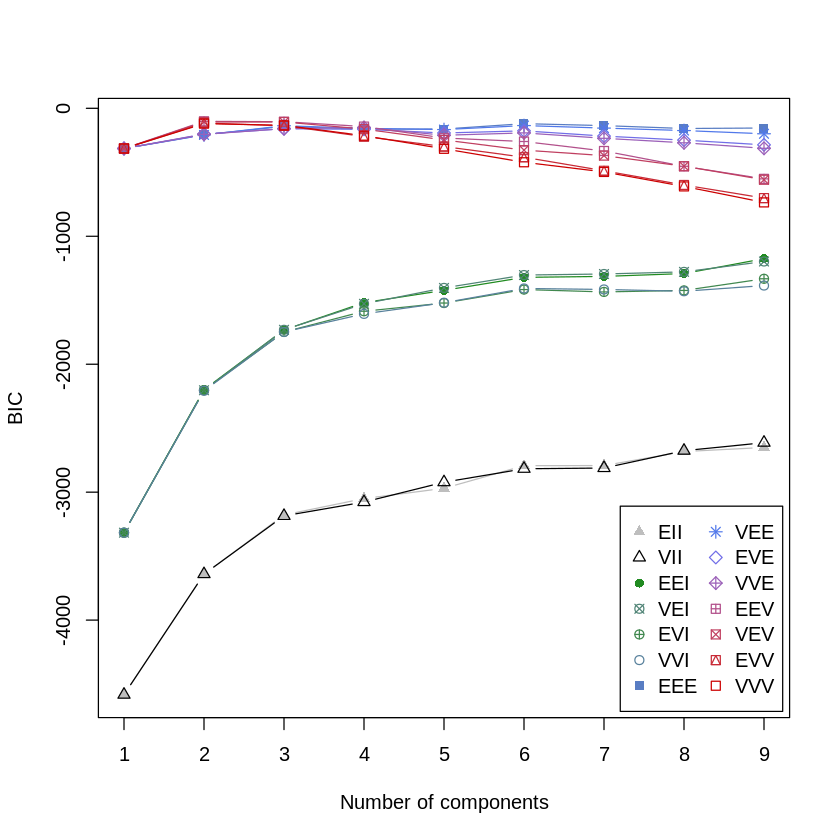

In [ ]:
#install.packages("mclust")
library(mclust)

datos <-read.table("semillas1.txt",dec=".")
# Asumiendo que las características numéricas de semillas están en X_semillas
# Mclust evaluará automáticamente el mejor número de grupos (por defecto G=1:9)
modelo_mclust <- Mclust(datos)

# El resumen nos mostrará el modelo óptimo y la cantidad de grupos elegida
summary(modelo_mclust)

# Graficar el BIC para ver los resultados de los distintos modelos evaluados
plot(modelo_mclust, what = "BIC")

Al ejecutar Mclust(datos) sin especificar el número de grupos, el algoritmo evaluó automáticamente 14 configuraciones distintas de matrices de covarianza para G = 1 a 9 componentes. El modelo seleccionado como óptimo fue el EEV con G = 2 componentes (BIC = -101.75).
En el gráfico BIC se observa que los modelos del grupo superior (curvas cercanas a 0, principalmente EEV, VEE, EVE y similares) alcanzan sus valores máximos en torno a G = 2 o G = 3, mientras que los modelos más restrictivos como VII y VVI (curvas verdes y negras) tienen un desempeño notablemente peor. El primer máximo local claro se produce en G = 2, lo que justifica la elección del modelo por parsimonia.

#**TAREA ANTERIOR {**

<pre>
# Carga de datos
datos_originales &lt;- read.csv(&quot;Grupo4.csv&quot;, sep=&quot;;&quot;, dec=&quot;.&quot;, header=TRUE)

# Extraer todas las columnas salvo las dos ultimas (contaminacion y alerta)
datos_cluster &lt;- datos_originales[, 1:(ncol(datos_originales)-2)]

# Eliminar filas con valores nulos (NA)
datos_cluster &lt;- na.omit(datos_cluster)

# Filtrar valores físicos imposibles (menores a cero) según sugerencia del PCA
datos_cluster &lt;- datos_cluster[datos_cluster$pm25 &gt;= 0 &amp; datos_cluster$no2 &gt;= 0, ]

# Escalar los datos:
# K-means agrupa usando distancias euclidianas. Si no escalamos, las variables
# con magnitudes grandes (como trafico) dominaran la formacion de grupos.
datos_scaled &lt;- scale(datos_cluster)

# Cargar librería cluster
if (!require(&quot;cluster&quot;)) {
  install.packages(&quot;cluster&quot;)
  library(cluster)
}

# Método del Codo (WSS)
set.seed(123)
k.max &lt;- 10

# Calculamos la suma de cuadrados intra-cluster (WSS) para k de 1 a 10
wss &lt;- sapply(1:k.max, function(k){
  kmeans(datos_scaled, centers = k, nstart = 25, iter.max = 1000)$tot.withinss
})

# Cálculo y Gráfico del Gap Estadístico
set.seed(123) # Fijar semilla para reproducibilidad
gap_stat &lt;- clusGap(datos_scaled,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)

# Ejecutar K-means con el K optimo
k0 &lt;- 4
set.seed(123)
cl &lt;- kmeans(datos_scaled, centers = k0, iter.max = 1000, nstart = 25)

# Añadir la asignacion del cluster a nuestros datos originales limpios
# (usamos datos_cluster para ver los valores reales, no los escalados)
datos_finales &lt;- data.frame(datos_cluster, Cluster = as.factor(cl$cluster))

# Calcular la media de cada variable segun el grupo asignado
medias_grupos &lt;- aggregate(. ~ Cluster, data = datos_finales, mean)

</pre>

#**}**

### **1. c)** Al observar los resultados impresos por tu código, debes redactar tu comentario enfocándote en estos tres puntos que te entrega la función Mclust:

* **Número óptimo de grupos (G):**
   Señala cuántos clústers escogió el modelo basándose en el máximo local del Criterio de Información Bayesiano (BIC). Comenta si este número tiene sentido empírico para ti.

* **El tipo de modelo seleccionado:**
   Mclust no solo busca la cantidad de grupos, sino la geometría de las matrices de covarianza. Revisa qué modelo determinó como óptimo (por ejemplo, EII para esféricos de igual volumen, o VVV para elipsoidales de volumen y forma variable). Esto te indica cómo se distribuyen tus datos en el espacio.

*  **Clustering Probabilístico:**
   Destaca que los resultados generaron probabilidades de pertenencia para cada observación (gracias al paso E del algoritmo), lo que permite manejar la incertidumbre de los puntos que se encuentran en las fronteras entre dos grupos.

### Comparación: K-Means vs. Modelo de Mezclas de Normales (GMM)

A partir de los resultados obtenidos y la teoría subyacente, se establecen las siguientes diferencias clave entre ambos algoritmos de agrupamiento:

| Característica | K-Means | GMM (Modelo de Mezclas de Normales) |
| :--- | :--- | :--- |
| **Función de Pérdida** | Minimiza la suma de los cuadrados de la distancia Euclidiana respecto al centroide. | Minimiza el negativo del logaritmo de la verosimilitud (maximiza la log-verosimilitud). |
| **Tipo de Asignación (Paso E)** | **Determinista:** Asigna cada observación de forma absoluta a un único clúster. | **Probabilística:** Calcula la probabilidad *a posteriori* de que un punto pertenezca a cada componente. |
| **Forma de los Grupos** | Asume estrictamente grupos **esféricos** y con la misma probabilidad/tamaño para cada uno. | Es flexible; permite modelar grupos con distintas **formas (elipsoides)**, volúmenes y orientaciones variando la matriz de covarianza. |
| **Optimización (Paso M)** | Optimiza únicamente la posición de los centroides de los grupos. | Optimiza los parámetros de cada distribución Gaussiana (media, covarianza y probabilidad previa). |
| **Sensibilidad** | Pequeñas variaciones en los datos pueden significar un cambio brusco de grupo (sensible a *outliers*). | Las transiciones y solapamientos se manejan de manera suave gracias al clustering probabilístico. |

**Conclusión:**
K-Means puede considerarse matemáticamente como un caso especial (y simplificado) de GMM. Específicamente, cuando las matrices de covarianza en GMM son esféricas e iguales para todos los componentes ($\Sigma_k = \sigma^2 I$), ambos métodos coinciden. Al utilizar `Mclust`, el algoritmo tiene la libertad de ajustarse mejor a la geometría real de los datos si estos no presentan una estructura perfectamente esférica.

### Ejercicio 2

**a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.**

*   **Purity (Pureza):** Es una métrica de evaluación externa que mide la homogeneidad de los clústeres. Se calcula asignando a cada clúster la clase más frecuente que contiene y, posteriormente, midiendo la proporción de observaciones totales que fueron correctamente asignadas bajo esa suposición.
*   **Rand Index (Índice de Rand):** Mide la similitud entre el agrupamiento obtenido por el modelo y las clases reales evaluando todos los pares posibles de observaciones. Calcula el porcentaje de pares que son agrupados de forma concordante (es decir, pares que están juntos en el mismo grupo en la realidad y en la predicción, o separados en ambos).
*   **Mutual Information (Información Mutua):** Basado en la teoría de la información, evalúa cuánto conocimiento (reducción de la incertidumbre) nos proporciona el agrupamiento predicho sobre las clases reales subyacentes.



### b) Calcule alguna de las medidas de calidad estudiadas para los agrupamientos obtenidos con KMeans (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos.

In [ ]:
library(mclust)

# 1. Cargar el dataset de semillas
datos_semillas_completos <- read.table("semillas.txt")

# 2. Separar las características (V1 a V6) de las etiquetas reales (V7)
# Se asume que V7 tiene las clases: 1 (Kama), 2 (Rosa), 3 (Canadian)
X_semillas <- datos_semillas_completos[, 1:6]
etiquetas_reales <- datos_semillas_completos[, 7]

# 3. Aplicar K-Means forzando k=3 (Calculado por metodo del Codo)
set.seed(123)
modelo_kmeans_sem <- kmeans(X_semillas, centers = 3, nstart = 25)

# 4. Aplicar GMM (Mclust) a los mismos datos
modelo_gmm_sem <- Mclust(X_semillas, G = 3) # Se fija G=3 para una comparación justa

# 5. Calcular el Adjusted Rand Index para ambos modelos
ari_kmeans <- adjustedRandIndex(etiquetas_reales, modelo_kmeans_sem$cluster)
ari_gmm <- adjustedRandIndex(etiquetas_reales, modelo_gmm_sem$classification)

# Mostrar los resultados
cat("Adjusted Rand Index (K-Means):", ari_kmeans, "\n")
cat("Adjusted Rand Index (GMM):", ari_gmm, "\n")

Adjusted Rand Index (K-Means): 0.7166199 
Adjusted Rand Index (GMM): 0.8051487 



# Propuesta

Al calcular el Adjusted Rand Index (ARI) para ambos modelos sobre el dataset semillas.txt, comparando los clusters obtenidos contra las etiquetas reales de la columna V7, se obtuvieron los siguientes resultados:

K-Means: ARI = 0.7166
GMM (Mclust): ARI = 0.8051

Ambos modelos logran un agrupamiento considerablemente bueno (ARI > 0.7), lo que indica que ambos recuperan en gran medida la estructura real de las tres variedades de semillas. Sin embargo, el GMM supera a K-Means en ~0.09 puntos, lo cual es consistente con las diferencias teóricas entre ambos métodos.
Esta ventaja del GMM se explica porque K-Means asume grupos esféricos de igual tamaño y realiza asignaciones deterministas, lo que puede ser una restricción cuando las variedades de semillas no tienen la misma dispersión en todas las variables. El GMM, en cambio, ajusta una matriz de covarianza por componente, lo que le permite adaptarse a grupos con formas elipsoidales distintas. Adicionalmente, la asignación probabilística del GMM maneja mejor las observaciones que se encuentran en la frontera entre dos variedades, reduciendo los errores de clasificación en esas zonas de solapamiento.

### Ejercicio 3: Análisis de Agrupamiento de Datos Asignados (Grupo 4)

#### a) Análisis de agrupamiento utilizando GMM

Para comenzar, cargamos los datos correspondientes al `Grupo4.csv`. Al revisar la estructura de los datos, notamos que están separados por punto y coma (`;`) y contienen una variable lógica (`alerta`), la cual excluiremos del análisis para enfocarnos únicamente en las variables numéricas continuas (`pm25`, `no2`, `trafico`, `viento`, `contaminacion`).

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEE (ellipsoidal, equal shape and orientation) model with 2 components: 

 log-likelihood   n df      BIC       ICL
      -9305.343 475 27 -18777.1 -18779.44

Clustering table:
  1   2 
457  18 

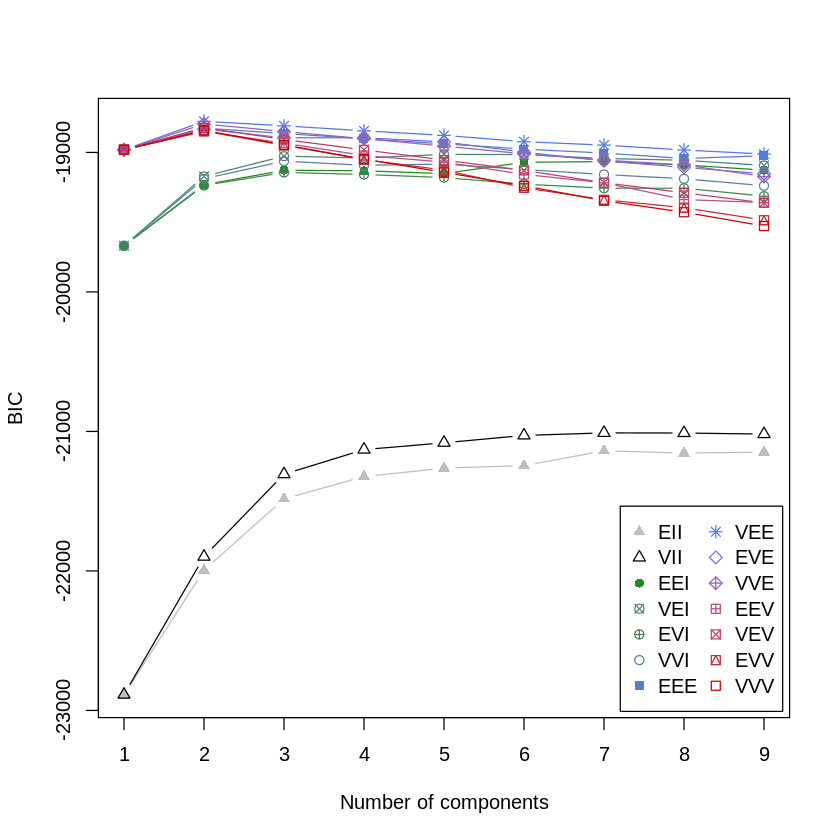

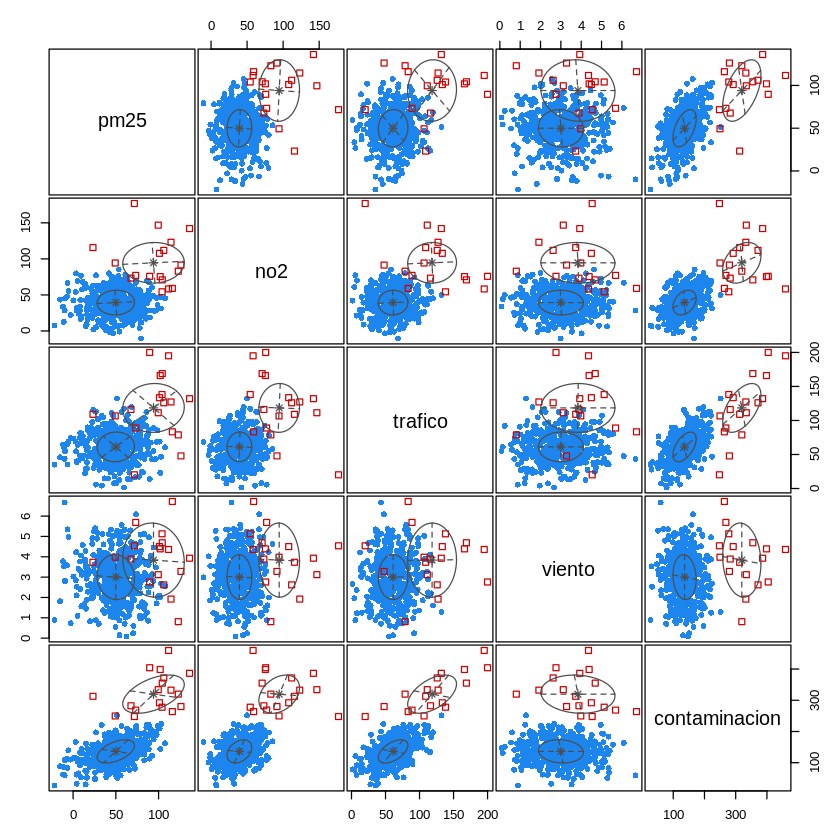

In [ ]:
# 1. Carga y preparación de los datos
datos_grupo4 <- read.csv("Grupo4.csv", sep=";")

# Seleccionamos solo las variables numéricas continuas para el clustering
# (Se excluye la columna 'alerta' ya que es booleana)
datos_clust <- datos_grupo4[, c("pm25", "no2", "trafico", "viento", "contaminacion")]

# 2. Aplicación de GMM (Mclust)
# Dejamos que la función determine el número óptimo de clústers y el tipo de modelo usando el BIC
modelo_gmm <- Mclust(datos_clust)

# Mostrar el resumen del modelo seleccionado
summary(modelo_gmm)

# Visualizar el criterio BIC para los distintos modelos y cantidades de grupos
plot(modelo_gmm, what = "BIC")

# Visualizar la clasificación resultante
plot(modelo_gmm, what = "classification")

Al aplicar Mclust sin definir el número de grupos sobre las variables pm25, no2, trafico, viento y contaminacion del dataset Grupo4, el modelo seleccionado fue el VEE con G = 2 componentes (BIC = -18777.1).
El modelo VEE corresponde a clusters elipsoidales con volumen variable, pero igual forma y orientación. Esto indica que los dos grupos comparten una geometría similar en el espacio de variables, pero difieren en su tamaño/densidad.
El gráfico BIC muestra que prácticamente todos los modelos alcanzan su máximo en G = 2, con una caída posterior al aumentar el número de componentes, lo que confirma que 2 es el número óptimo de grupos. Los modelos más restrictivos (VII, EII) tienen un desempeño considerablemente peor, lo que refuerza que la estructura de los datos no es esférica.
La tabla de clustering revela una distribución muy asimétrica: Cluster 1: 457 observaciones y Cluster 2: 18 observaciones. Esto sugiere que el GMM identificó un grupo mayoritario que representa condiciones normales de calidad del aire, y un grupo minoritario de solo 18 registros que corresponde a situaciones atípicas o de alta contaminación — consistente con lo que podría representar la variable alerta que fue excluida del análisis. El gráfico de clasificación por pares de variables muestra claramente este comportamiento: el cluster 2 (cuadrados rojos) agrupa las observaciones con valores más extremos en pm25, no2 y contaminacion.

### Ejercicio 3b


###